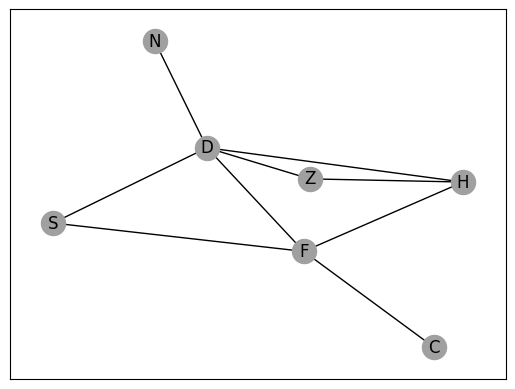

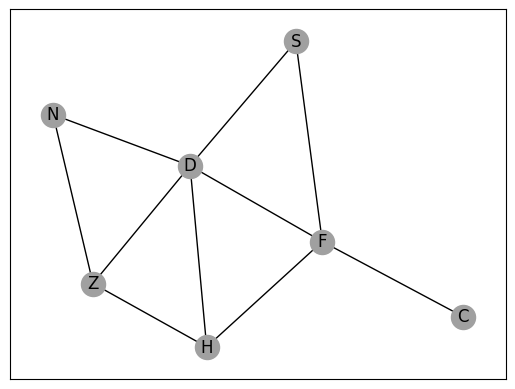

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G_a = nx.Graph()
G_b = nx.Graph()

G_a.add_edge("S", "F")
G_a.add_edge("S", "D")
G_a.add_edge("F", "C")
G_a.add_edge("F", "H")
G_a.add_edge("D", "H")
G_a.add_edge("D", "N")
G_a.add_edge("H", "Z")
G_a.add_edge("D", "Z")
G_a.add_edge("F", "D")

G_b.add_edge("S", "F")
G_b.add_edge("S", "D")
G_b.add_edge("F", "C")
G_b.add_edge("F", "H")
G_b.add_edge("D", "H")
G_b.add_edge("D", "N")
G_b.add_edge("H", "Z")
G_b.add_edge("Z", "N")
G_b.add_edge("D", "Z")
G_b.add_edge("F", "D")


a_pos = nx.spring_layout(G_a, seed= 2025)
b_pos = nx.spring_layout(G_b, seed= 2025)

nx.draw_networkx_nodes(
    G_a, 
    pos= a_pos,
    node_color= "#a0a0a0",
    node_shape= "o"
)
nx.draw_networkx_labels(
    G_a, 
    pos= a_pos,
    font_color= "#000000"
)
nx.draw_networkx_edges(
    G_a, 
    pos= a_pos,
)
plt.show()

nx.draw_networkx_nodes(
    G_b, 
    pos= b_pos,
    node_color= "#a0a0a0"
)
nx.draw_networkx_labels(
    G_b, 
    pos= b_pos,
    font_color= "#000000"
)
nx.draw_networkx_edges(
    G_b, 
    pos= b_pos,
)
plt.show()

[('f1', 'D'), ('f1', 'Z'), ('f1', 'H'), ('f2', 'D'), ('f2', 'F'), ('f2', 'H'), ('f3', 'D'), ('f3', 'F'), ('f3', 'S'), ('f4', 'D'), ('f4', 'N'), ('f5', 'F'), ('f5', 'C')]


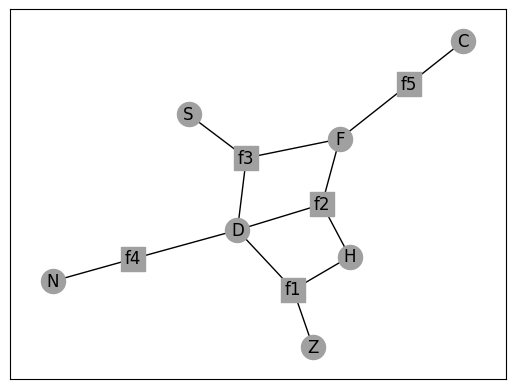

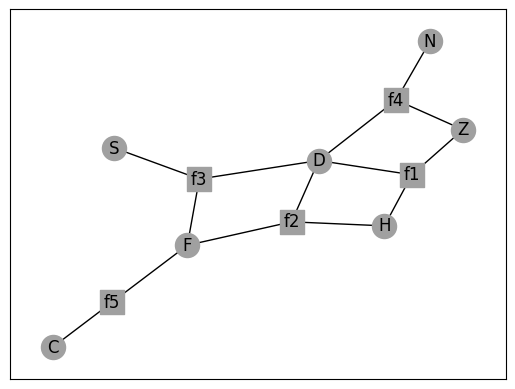

In [34]:
G_af = nx.Graph()
G_bf = nx.Graph()

G_af.add_node("f1", factor_node= True)
G_af.add_node("f2", factor_node= True)
G_af.add_node("f3", factor_node= True)
G_af.add_node("f4", factor_node= True)
G_af.add_node("f5", factor_node= True)
G_af.add_edge("f1", "D")
G_af.add_edge("f1", "Z")
G_af.add_edge("f1", "H")
G_af.add_edge("f2", "D")
G_af.add_edge("f2", "F")
G_af.add_edge("f2", "H")
G_af.add_edge("f3", "D")
G_af.add_edge("f3", "F")
G_af.add_edge("f3", "S")
G_af.add_edge("f3", "D")
G_af.add_edge("f4", "D")
G_af.add_edge("f4", "N")
G_af.add_edge("f5", "F")
G_af.add_edge("f5", "C")

G_bf.add_node("f1", factor_node= True)
G_bf.add_node("f2", factor_node= True)
G_bf.add_node("f3", factor_node= True)
G_bf.add_node("f4", factor_node= True)
G_bf.add_node("f5", factor_node= True)
G_bf.add_edge("f1", "D")
G_bf.add_edge("f1", "Z")
G_bf.add_edge("f1", "H")
G_bf.add_edge("f2", "D")
G_bf.add_edge("f2", "F")
G_bf.add_edge("f2", "H")
G_bf.add_edge("f3", "D")
G_bf.add_edge("f3", "F")
G_bf.add_edge("f3", "S")
G_bf.add_edge("f3", "D")
G_bf.add_edge("f4", "D")
G_bf.add_edge("f4", "N")
G_bf.add_edge("f4", "Z")
G_bf.add_edge("f5", "F")
G_bf.add_edge("f5", "C")

factor_nodes_a = [nn for nn, attrs in G_af.nodes(data= True) if attrs.get("factor_node")]
base_nodes_a = [nn for nn in G_af.nodes if nn not in factor_nodes_a]

factor_nodes_b = [nn for nn, attrs in G_bf.nodes(data= True) if attrs.get("factor_node")]
base_nodes_b = [nn for nn in G_bf.nodes if nn not in factor_nodes_b]

af_pos = nx.spring_layout(G_af, seed= 1020)
# af_pos = nx.bipartite_layout(G_af, factor_nodes_a)
bf_pos = nx.spring_layout(G_bf, seed= 8888)

print(G_af.edges)

nx.draw_networkx_nodes(
    G_af,
    af_pos, 
    factor_nodes_a,
    node_shape= "s",
    node_color= "#a0a0a0",
)
nx.draw_networkx_nodes(
    G_af,
    af_pos, 
    base_nodes_a,
    node_shape= "o",
    node_color= "#a0a0a0",
)
nx.draw_networkx_labels(
    G_af,
    af_pos,
)
nx.draw_networkx_edges(
    G_af,
    af_pos
)
plt.show()

nx.draw_networkx_nodes(
    G_bf,
    bf_pos, 
    factor_nodes_b,
    node_shape= "s",
    node_color= "#a0a0a0",
)
nx.draw_networkx_nodes(
    G_bf,
    bf_pos, 
    base_nodes_b,
    node_shape= "o",
    node_color= "#a0a0a0",
)
nx.draw_networkx_labels(
    G_bf,
    bf_pos,
)
nx.draw_networkx_edges(
    G_bf,
    bf_pos
)
plt.show()

## pgmpy

In [9]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

e_list = [
    ("S", "F"),
    ("S", "D"),
    ("F", "C"),
    ("F", "H"),
    ("D", "H"),
    ("D", "Z"),
    ("D", "N"),
    ("H", "Z"),
]

model = DiscreteBayesianNetwork(e_list)

cpd_s = TabularCPD(
    variable= "S",
    variable_card= 2,
    values= [[0.5], [0.5]],
    state_names= {"S": ['winter', 'summer']}
)

cpd_f = TabularCPD(
    variable= "F",
    variable_card= 2,
    values= [[0.6, 0.9], 
             [0.4, 0.1]],
    evidence= ["S"],
    evidence_card= [2],
    state_names= {"S": ['winter', 'summer'],
                  "F": ['False', 'True']}
)

cpd_d = TabularCPD(
    variable= "D",
    variable_card= 2,
    values= [[0.9, 0.7], 
             [0.1, 0.3]],
    evidence= ["S"],
    evidence_card= [2],
    state_names= {"S": ['winter', 'summer'],
                  "D": ['False', 'True']}
)

cpd_c = TabularCPD(
    variable= "C",
    variable_card= 2,
    values= [[0.9, 0.2], 
             [0.1, 0.8]],
    evidence= ["F"],
    evidence_card= [2],
    state_names= {"F": ['False', 'True'],
                  "C": ['False', 'True']}
)

cpd_h = TabularCPD(
    variable= "H",
    variable_card= 2,
    values= [[0.7, 0.2, 0.2, 0.1], 
             [0.3, 0.8, 0.8, 0.9]],
    evidence= ["F", "D"],
    evidence_card= [2, 2],
    state_names= {"F": ['False', 'True'],
                  "D": ['False', 'True'],
                  "H": ['False', 'True'],}
)

cpd_n = TabularCPD(
    variable= "N",
    variable_card= 2,
    values= [[0.8, 0.2], 
             [0.2, 0.8]],
    evidence= ["D"],
    evidence_card= [2],
    state_names= {"D": ['False', 'True'],
                  "N": ['False', 'True'],}
)

cpd_z = TabularCPD(
    variable= "Z",
    variable_card= 2,
    values= [[0.8, 0.2, 0.4, 0.1], 
             [0.2, 0.8, 0.6, 0.9]],
    evidence= ["H", "D"],
    evidence_card= [2, 2],
    state_names= {"H": ['False', 'True'],
                  "D": ['False', 'True'],
                  "Z": ['False', 'True'],}
)

model.add_cpds(cpd_s, cpd_f, cpd_d, cpd_c, cpd_h, cpd_n, cpd_z)
model.check_model()

True

In [10]:
model.get_cpds()

[<TabularCPD representing P(S:2) at 0x14cc37a4d30>,
 <TabularCPD representing P(F:2 | S:2) at 0x14cc37a4dc0>,
 <TabularCPD representing P(D:2 | S:2) at 0x14cc37a4d60>,
 <TabularCPD representing P(C:2 | F:2) at 0x14cc37a4d00>,
 <TabularCPD representing P(H:2 | F:2, D:2) at 0x14cc37a4df0>,
 <TabularCPD representing P(N:2 | D:2) at 0x14cc37a4d90>,
 <TabularCPD representing P(Z:2 | H:2, D:2) at 0x14cc37a4f70>]

In [11]:
model.local_independencies(["S", "F", "D", "C", "H", "N", "Z"])

(F ⟂ N, D | S)
(D ⟂ C, F | S)
(C ⟂ N, Z, D, S, H | F)
(H ⟂ N, S, C | F, D)
(N ⟂ Z, H, F, S, C | D)
(Z ⟂ N, S, C, F | H, D)

In [14]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)
query_a = infer.query(['F'])
query_b = infer.query(['F'], evidence= {"S": "winter"})
query_c = infer.query(['F'], evidence= {"S": "winter", "D": "True", "H": "True"})
print(query_a)
print(query_b)
print(query_c)

+----------+----------+
| F        |   phi(F) |
+==========+==========+
| F(False) |   0.7500 |
+----------+----------+
| F(True)  |   0.2500 |
+----------+----------+
+----------+----------+
| F        |   phi(F) |
+==========+==========+
| F(False) |   0.6000 |
+----------+----------+
| F(True)  |   0.4000 |
+----------+----------+
+----------+----------+
| F        |   phi(F) |
+==========+==========+
| F(False) |   0.5714 |
+----------+----------+
| F(True)  |   0.4286 |
+----------+----------+
